In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from bilby.gw.conversion import lambda_1_lambda_2_to_lambda_tilde, lambda_1_lambda_2_to_delta_lambda_tilde, lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2

In [9]:
wide_df = pd.read_csv("../../events/gw/gw_params_wide.dat", sep=" ")
events = pd.read_csv("events.dat", sep=" ")

In [4]:
n_coll = np.sum(events["prompt_collapse"] ==1 )
n_tot = events.shape[0]
pop_coll_share = np.sum(wide_df["prompt_collapse"]==1)/wide_df.shape[0]

print(f"Prompt collapse: {n_coll}/{n_tot}, {n_coll/n_tot:.3f}, ", pop_coll_share)

Prompt collapse: 8/28, 0.286,  0.7548668655397194


In [4]:
log10_mej_wind = events["log10_mej_wind"]
zeta = 10**(events["log10_mej_wind"] - events["log10_mdisk"])

print("wind quantile: ", np.quantile(log10_mej_wind, 0.05))
print("zeta quantile: ", np.quantile(zeta, 0.05))

wind quantile:  -1.859757434488813
zeta quantile:  0.14157329951405434


(array([4., 2., 2., 6., 6., 0., 1., 2., 2., 3.]),
 array([1.2147153 , 1.28973318, 1.36475106, 1.43976894, 1.51478682,
        1.5898047 , 1.66482258, 1.73984047, 1.81485835, 1.88987623,
        1.96489411]),
 <BarContainer object of 10 artists>)

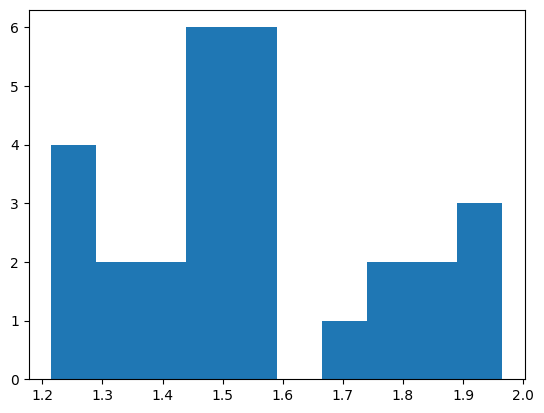

In [13]:
plt.hist(events["mass_1_source"])

In [7]:
events.loc[[13,17,26], "snr"]

13     89.645
17    105.778
26    235.961
Name: snr, dtype: float64

In [10]:
np.sort(events["snr"])

array([ 12.873,  13.97 ,  15.215,  15.562,  15.602,  17.442,  18.353,
        19.491,  19.566,  20.022,  20.235,  22.02 ,  22.313,  22.405,
        22.739,  25.315,  25.864,  26.259,  27.02 ,  28.971,  29.978,
        30.769,  33.935,  38.708,  58.396,  89.645, 105.778, 235.961])

In [3]:
print("SNR min max: ", np.min(events["snr"]), np.max(events["snr"]))

SNR min max:  12.873 235.961


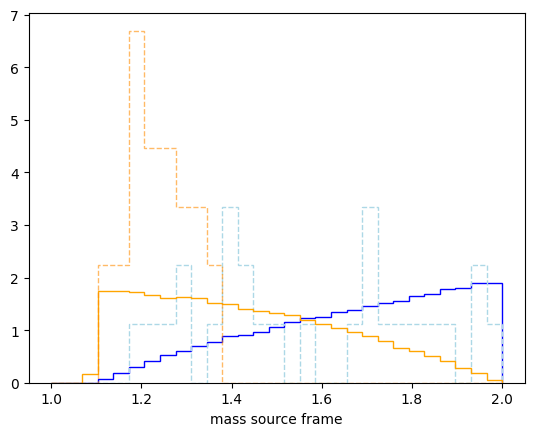

In [6]:
bins = np.linspace(1, 2, 30)

plt.hist(wide_df["mass_1_source"], bins=bins, density=True, histtype="step", color="blue")
plt.hist(events.loc[:, "mass_1_source"], bins=bins, density=True, histtype="step", color="lightblue", linestyle="dashed")

plt.hist(wide_df["mass_2_source"], bins=bins, density=True, color="orange", histtype="step")
plt.hist(events.loc[:, "mass_2_source"], bins=bins, density=True, histtype="step", alpha=0.6, color="darkorange", linestyle="dashed")


plt.xlabel("mass source frame")
plt.show()

In [7]:
events["mass_ratio"] = events["mass_2"] / events["mass_1"]